# EDA — API `atencionsismo.cali.gov.co`

Análisis exploratorio completo de la salida de la **API de casos Visitado Crítico**
de la plataforma de atención al sismo de Cali.

**Qué entrega la API:** la lista de evaluaciones técnicas críticas (tipo de colapso
**A** o **B**) completadas en un rango de fechas, con:

- Ubicación (dirección, coordenadas, comuna, barrio)
- Datos de ingreso del reporte (cómo se reportó al inicio)
- Contacto de la persona afectada e inmueble
- Personal de ingreso y técnico de verificación (ingeniero/arquitecto)
- Evaluación técnica completa (daños, víctimas, habitabilidad, concepto)
- Mensajes de la conversación del caso (texto y autor)

**Criterio de inclusión ("Visitado Crítico"):** un caso entra en la respuesta solo si su evaluación cumple:

1. `visitado === true`
2. Tipo de colapso **verificado** A o B (el del ingreso no cuenta para el filtro)
3. No es visita fallida (`puedeEvaluar` distinto de `false`)
4. `evaluacion.creado_utc` está dentro de `[desde_utc, hasta_utc]` (inclusive)


## Endpoint

La API expone **un único endpoint**:

```
GET https://atencionsismo.cali.gov.co/api/operario/reports/visitados-criticos
```

Host fijo de producción: `atencionsismo.cali.gov.co` (siempre HTTPS).

### Parámetros de consulta

| Parámetro | Tipo | Obligatorio | Descripción |
| --- | --- | --- | --- |
| `desde_utc` | entero | sí | Inicio del rango (Unix **milisegundos** UTC, inclusive) |
| `hasta_utc` | entero | sí | Fin del rango (Unix **milisegundos** UTC, inclusive) |

Reglas: ambos deben ser enteros, `desde_utc <= hasta_utc`, y el filtro aplica sobre
la **fecha de creación de la evaluación** (`evaluacion.creado_utc`), no la del
reporte de ingreso.

Ejemplo:

```
https://atencionsismo.cali.gov.co/api/operario/reports/visitados-criticos?desde_utc=1722470400000&hasta_utc=1725148799999
```

### Autenticación

HTTP **Basic Auth** (correo + contraseña habilitados para la API). En este proyecto
las credenciales viven en `integracion_F1/.env` (`VISITADOS_API_USER`,
`VISITADOS_API_PASS`), cargadas automáticamente por `integracion.config`.

### Errores

Respuestas de error en JSON: `{ "error": "mensaje en español" }`.

| HTTP | Cuándo |
| --- | --- |
| `400` | Falta `desde_utc`/`hasta_utc`, no son enteros, o `desde_utc > hasta_utc` |
| `401` | Sin Basic Auth o credenciales inválidas |
| `403` | Correo habilitado pero aún sin contraseña creada en el portal |
| `500` | Error interno |


In [43]:
import json
import sys
import time
from datetime import datetime, timedelta, timezone

import pandas as pd
import requests

# Reutilizamos el cliente del subproyecto: importar config carga el .env
sys.path.insert(0, "integracion_F1")
from integracion.api_visitados import API_URL, PASS_ENV, USER_ENV, DEFAULT_USER
import os

BOGOTA_TZ = timezone(timedelta(hours=-5), "America/Bogota")

def ms_a_fecha(ms):
    """Unix ms UTC -> fecha legible en hora de Bogotá."""
    if ms is None:
        return None
    return datetime.fromtimestamp(ms / 1000, tz=BOGOTA_TZ).strftime("%Y-%m-%d %H:%M:%S")

desde_utc = 0                      # todo el histórico
hasta_utc = int(time.time() * 1000)

usuario = os.environ.get(USER_ENV, "").strip() or DEFAULT_USER
clave = os.environ.get(PASS_ENV, "").strip()
assert clave, f"{PASS_ENV} no está definida en integracion_F1/.env"

resp = requests.get(API_URL, params={"desde_utc": desde_utc, "hasta_utc": hasta_utc},
                    auth=(usuario, clave), timeout=120)
resp.raise_for_status()
data = resp.json()
print(f"HTTP {resp.status_code} — {len(resp.content):,} bytes")
print(f"Casos devueltos: {data['cantidad']}")

HTTP 200 — 1,636,143 bytes
Casos devueltos: 424


## Respuesta exitosa (`200`) — nivel superior

| Campo | Tipo | Descripción |
| --- | --- | --- |
| `ok` | boolean | Siempre `true` si la petición fue válida |
| `cantidad` | number | Número de elementos en `casos` |
| `generado_utc` | number | Momento en que se generó la respuesta (ms UTC) |
| `desde_utc` | number | Eco del parámetro de entrada |
| `hasta_utc` | number | Eco del parámetro de entrada |
| `casos` | array | Lista de casos críticos (una entrada **por evaluación**) |

Todos los campos `*_utc` son enteros en **milisegundos** desde el epoch Unix (UTC).


In [44]:
meta = {k: v for k, v in data.items() if k != "casos"}
meta_legible = {**meta,
                "generado_utc (Bogotá)": ms_a_fecha(meta["generado_utc"]),
                "hasta_utc (Bogotá)": ms_a_fecha(meta["hasta_utc"])}
print(json.dumps(meta_legible, indent=2, ensure_ascii=False))
casos = data["casos"]

{
  "ok": true,
  "cantidad": 424,
  "generado_utc": 1787179666473,
  "desde_utc": 0,
  "hasta_utc": 1787179664238,
  "generado_utc (Bogotá)": "2026-08-19 17:47:46",
  "hasta_utc (Bogotá)": "2026-08-19 17:47:44"
}


## Esquema de cada caso (`casos[]`)

Cada elemento del arreglo `casos` es **una evaluación** de un reporte (un mismo
reporte con visitas repetidas aparece varias veces con el mismo `id`).

### 1. Identificación y ubicación (nivel raíz del caso)

| Campo | Tipo | Descripción |
| --- | --- | --- |
| `id` | string | ID del reporte |
| `estado` | `"critico"` | Código fijo |
| `estadoEtiqueta` | `"Visitado Crítico"` | Etiqueta en español |
| `direccion` | string | Dirección |
| `lat` / `lng` | number | Coordenadas |
| `placeId` | string | `place_id` de Google Places, o `manual:lat,lng` / `verified:lat,lng` para ingresos manuales |
| `comuna` | number \| null | Código de comuna |
| `comunaEtiqueta` | string \| null | Ej. `"Comuna 05"` |
| `barrio` | string \| null | Nombre del barrio |
| `resumenUnidad` | string \| null | Resumen de unidad / edificio |

> **Nota de privacidad:** los ejemplos de este notebook enmascaran datos personales
> (nombres, teléfonos, cédulas, correos, matrículas) porque la API los devuelve en claro.


In [45]:
PII = {"nombre", "telefono", "cedula", "correo", "matriculaProfesional"}

def redactar(obj):
    """Enmascara campos personales en cualquier estructura anidada."""
    if isinstance(obj, dict):
        return {k: ("***" if k in PII and obj[k] else redactar(v)) for k, v in obj.items()}
    if isinstance(obj, list):
        return [redactar(x) for x in obj]
    return obj

ej = casos[0]
raiz = {k: v for k, v in ej.items()
        if k not in ("ingreso", "contacto", "inmueble", "operarioIngreso",
                     "tecnicoVerificacion", "evaluacion", "mensajes")}
print(json.dumps(redactar(raiz), indent=2, ensure_ascii=False))

{
  "id": "f18f5852-78b7-4b19-8db6-ff9517f79b29",
  "estado": "critico",
  "estadoEtiqueta": "Visitado Crítico",
  "direccion": "Avenida 5n   calle 49, La flora, Cali",
  "lat": 3.48795426,
  "lng": -76.522085171,
  "placeId": "arcgis:4e1d9af4-aef8-4a5d-a58b-6171c0bdf647",
  "comuna": 2,
  "comunaEtiqueta": "Comuna 02",
  "barrio": "La Flora",
  "resumenUnidad": null,
  "verificacion_asignada_utc": 1786467600000
}


### 2. `ingreso` — cómo se reportó el caso al inicio

| Campo | Tipo | Descripción |
| --- | --- | --- |
| `descripcion` | string \| null | Descripción del caso |
| `tipoColapso` | string \| null | Código A–F **del ingreso** (no define el filtro) |
| `tipoColapsoEtiqueta` | string \| null | Etiqueta en español |
| `tipoInmueble` / `tipoInmuebleEtiqueta` | string \| null | Tipo de inmueble reportado |
| `nombreEdificio` / `numeroApartamento` / `numeroCasa` | string \| null | |
| `edificioCompleto` | boolean \| null | |
| `contacto` | objeto | `{ nombre, telefono, cedula }` |
| `creado_utc` | number | Creación del reporte (ms UTC) |
| `enviado_utc` | number \| null | Envío / submit |
| `estado` / `estadoEtiqueta` | string \| null | `draft`/`Borrador` \| `submitted`/`Enviado` |
| `completado` | boolean \| null | |


In [46]:
print(json.dumps(redactar(ej.get("ingreso") or {}), indent=2, ensure_ascii=False))

{
  "descripcion": "Migrado ArcGIS UGRD globalid=4e1d9af4-aef8-4a5d-a58b-6171c0bdf647",
  "tipoColapso": "B",
  "tipoColapsoEtiqueta": "RIESGO COLAPSO: Edificio daños graves, ladeados, a punto de caer",
  "tipoInmueble": "casa",
  "tipoInmuebleEtiqueta": "Casa",
  "nombreEdificio": null,
  "numeroApartamento": null,
  "numeroCasa": null,
  "edificioCompleto": false,
  "contacto": {
    "nombre": "***",
    "telefono": "***",
    "cedula": "***"
  },
  "creado_utc": 1786467600000,
  "enviado_utc": 1786467600000,
  "estado": "submitted",
  "estadoEtiqueta": "Enviado",
  "completado": true
}


### 3. `contacto` y `inmueble`

**`contacto`** — persona afectada: `{ nombre, telefono, cedula }`.

**`inmueble`** — inmueble *efectivo*: valores verificados en la evaluación cuando
existen; si no, los del ingreso.

| Campo | Tipo |
| --- | --- |
| `tipoInmueble` / `tipoInmuebleEtiqueta` | string |
| `nombreEdificio` | string \| null |
| `numeroApartamento` / `numeroCasa` | string \| null |
| `edificioCompleto` | boolean \| null |


In [47]:
print("contacto:")
print(json.dumps(redactar(ej.get("contacto") or {}), indent=2, ensure_ascii=False))
print("\ninmueble:")
print(json.dumps(redactar(ej.get("inmueble") or {}), indent=2, ensure_ascii=False))

contacto:
{
  "nombre": "***",
  "telefono": "***",
  "cedula": "***"
}

inmueble:
{
  "tipoInmueble": "casa",
  "tipoInmuebleEtiqueta": "Casa",
  "nombreEdificio": "Edificio Segovia",
  "numeroApartamento": null,
  "numeroCasa": null,
  "edificioCompleto": null
}


### 4. Personal — `operarioIngreso` y `tecnicoVerificacion`

**`operarioIngreso`** (o `null`) — quién registró el ingreso: `{ id, nombre, correo }`.

**`tecnicoVerificacion`** (o `null`) — ingeniero/arquitecto que verificó y evaluó:

| Campo | Tipo |
| --- | --- |
| `id` | string |
| `nombre` / `correo` / `profesion` | string \| null |
| `cedula` / `telefono` / `matriculaProfesional` | string \| null |
| `enfasis` | string \| null |
| `anosExperiencia` | number \| null |

**`verificacion_asignada_utc`**: number \| null — cuándo se asignó ese técnico.


In [48]:
con_tecnico = next((c for c in casos if c.get("tecnicoVerificacion")), ej)
print("operarioIngreso:")
print(json.dumps(redactar(con_tecnico.get("operarioIngreso") or {}), indent=2, ensure_ascii=False))
print("\ntecnicoVerificacion:")
print(json.dumps(redactar(con_tecnico.get("tecnicoVerificacion") or {}), indent=2, ensure_ascii=False))
print("\nverificacion_asignada_utc:", con_tecnico.get("verificacion_asignada_utc"),
      "->", ms_a_fecha(con_tecnico.get("verificacion_asignada_utc")))

operarioIngreso:
{
  "id": "2d06631d-8d31-462f-87c0-c857da8a6558",
  "nombre": "***",
  "correo": "***"
}

tecnicoVerificacion:
{
  "id": "65873885-bb8a-4fbb-b99d-e5c5e4b6b550",
  "nombre": "***",
  "correo": "***",
  "profesion": "Ingeniero Civil",
  "cedula": "***",
  "telefono": "***",
  "matriculaProfesional": "***",
  "enfasis": "Mc. ingeniería Civil",
  "anosExperiencia": 23
}

verificacion_asignada_utc: 1786467600000 -> 2026-08-11 12:00:00


### 5. `evaluacion` — evaluación técnica (la del rango)

Solo entran evaluaciones con visita realizada y tipo de colapso **A** o **B**.

| Campo | Tipo | Descripción |
| --- | --- | --- |
| `id` | string | ID de la evaluación |
| `creado_utc` | number | Momento en que se guardó |
| `visitado` | `true` | Siempre true en esta API |
| `puedeEvaluar` | `true` | Siempre true (visitas fallidas no entran) |
| `tipoColapso` | `"A"` \| `"B"` | Código **verificado** |
| `tipoColapsoEtiqueta` | string | Etiqueta en español |
| `tipoInmueble` / `tipoInmuebleEtiqueta` | string \| null | |
| `nombreEdificio` / `numeroApartamento` / `numeroCasa` | string \| null | |
| `edificioCompleto` | boolean \| null | |
| `pisosSobreNivel` / `sotanos` | number \| null | |
| `anioConstruccion` / `anioConstruccionEtiqueta` | string \| null | |
| `alcanceInspeccion` / `alcanceInspeccionEtiqueta` | string \| null | Interior / exterior |
| `danos` | array | Lista de daños observados (ver abajo) |
| `victimas` | objeto | Cifras de víctimas (ver abajo) |
| `habitabilidad` / `habitabilidadEtiqueta` | string \| null | |
| `conceptoTecnico` | string \| null | Concepto del técnico |
| `aspectosVisitaEspecializada` | string \| null | |
| `contacto` | objeto | `{ nombre, telefono, cedula }` |

**`danos[]`** — cada elemento:

| Campo | Descripción |
| --- | --- |
| `clave` | Identificador del campo (ej. `damageStairs`) |
| `campoEtiqueta` | Etiqueta en español (ej. "Daño en escaleras") |
| `valor` | `none` \| `leve` \| `moderado` \| `severo` |
| `valorEtiqueta` | Etiqueta en español |

**`victimas`:**

| Campo | Tipo |
| --- | --- |
| `fallecidos` / `atrapados` / `rescatados` | number \| null |
| `necesitaEvacuacion` | boolean \| null |
| `evacuados` / `porEvacuar` | number \| null |


In [49]:
ev = dict(ej.get("evaluacion") or {})
danos_completos = ev.get("danos") or []
ev["danos"] = danos_completos[:3] + (["… (recortado)"] if len(danos_completos) > 3 else [])
print(json.dumps(redactar(ev), indent=2, ensure_ascii=False))

{
  "id": "685d4e3d-d623-4033-9ff5-cf2681376cf8",
  "creado_utc": 1786467600000,
  "visitado": true,
  "puedeEvaluar": true,
  "tipoColapso": "B",
  "tipoColapsoEtiqueta": "RIESGO COLAPSO: Edificio daños graves, ladeados, a punto de caer",
  "tipoInmueble": "casa",
  "tipoInmuebleEtiqueta": "Casa",
  "nombreEdificio": "Edificio Segovia",
  "numeroApartamento": null,
  "numeroCasa": null,
  "edificioCompleto": null,
  "pisosSobreNivel": 4,
  "sotanos": 1,
  "anioConstruccion": null,
  "anioConstruccionEtiqueta": null,
  "alcanceInspeccion": null,
  "alcanceInspeccionEtiqueta": null,
  "danos": [
    {
      "clave": "damageWallsFacades",
      "campoEtiqueta": "Daños en muros, fachadas o entrepisos",
      "valor": "severo",
      "valorEtiqueta": "Severo"
    },
    {
      "clave": "damagePartitions",
      "campoEtiqueta": "Daños en muros divisorios o particiones",
      "valor": "severo",
      "valorEtiqueta": "Severo"
    },
    {
      "clave": "damageCeilings",
      "campoEtiqu

### 6. `mensajes[]` — conversación del caso

| Campo | Tipo | Descripción |
| --- | --- | --- |
| `id` | string | ID del mensaje |
| `texto` | string | Contenido |
| `creado_utc` | number | ms UTC |
| `autor` | objeto | `{ rol, rolEtiqueta, id, nombre, correo }` |

Valores de `autor.rol`: `ciudadano` \| `admin` \| `profesional` \| `rufe` \| `operario` \| `desconocido`.


In [50]:
con_msj = next((c for c in casos if c.get("mensajes")), None)
if con_msj:
    print(f"Caso {con_msj['id']}: {len(con_msj['mensajes'])} mensajes. Primer mensaje:")
    print(json.dumps(redactar(con_msj["mensajes"][0]), indent=2, ensure_ascii=False))
else:
    print("Ningún caso trae mensajes en este rango.")

Caso fb5902cf-e70d-49e2-a7e0-157cd86aadf2: 1 mensajes. Primer mensaje:
{
  "id": "492bff0b-4f13-451b-9402-6e02723f17a5",
  "texto": "[CSV estado: En Atención]\nafectacion forntal de vivienda por colapso de muros en manposteria, riesgo de colapso",
  "creado_utc": 1786815952978,
  "autor": {
    "rol": "desconocido",
    "rolEtiqueta": "Desconocido",
    "id": null,
    "nombre": null,
    "correo": null
  }
}


## Códigos frecuentes (valor → etiqueta)

**Tipo de colapso** (en `evaluacion.tipoColapso` solo aparecen A y B):

| Código | Etiqueta |
| --- | --- |
| `A` | COLAPSO TOTAL |
| `B` | RIESGO COLAPSO |
| `C` | COLAPSO PARCIAL |
| `D` | DAÑO ESTRUCTURAL |
| `E` | DAÑO MAMPOSTERÍA |
| `F` | NO SE EVIDENCIA NINGÚN DAÑO |

**Severidad de daño** (`danos[].valor`): `none` → Ninguno, `leve` → Leve, `moderado` → Moderado, `severo` → Severo.

**Habitabilidad:** `habitable` → Habitable, `partial` → Parcial, `not_habitable` → No habitable.

**Año de construcción:** `before_1930`, `1931_1984`, `1985_1997`, `from_1998`.

**Alcance de inspección:** `interior` (en el interior) \| `exterior` (no se permite el ingreso).

---

# EDA sobre los datos vivos

A partir de acá se analiza la salida real de la API en todo el histórico.


In [51]:
import matplotlib
import matplotlib.pyplot as plt

# Paleta (referencia dataviz): categórica fija + secuencial de un solo tono
AZUL, NARANJA = "#2a78d6", "#eb6834"
SEQ = {"none": "#d0d0cc", "leve": "#cde2fb", "moderado": "#5598e7", "severo": "#184f95"}
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.alpha": 0.25, "axes.axisbelow": True})

df = pd.json_normalize(casos, sep=".")
print(f"Filas (evaluaciones): {len(df)}  |  Columnas tras aplanar: {len(df.columns)}")
print(f"Reportes únicos (id): {df['id'].nunique()}")
rep = df["id"].value_counts()
print(f"Reportes con más de una evaluación: {(rep > 1).sum()} (máx {rep.max()} evaluaciones)")

Filas (evaluaciones): 424  |  Columnas tras aplanar: 85
Reportes únicos (id): 303
Reportes con más de una evaluación: 113 (máx 4 evaluaciones)


### Estructura y granularidad

La API devuelve **una fila por evaluación, no por reporte**: un reporte con visitas
repetidas aparece varias veces bajo el mismo `id`. El cliente del proyecto
(`api_visitados.casos_to_tabla`) deduplica quedándose con la evaluación más
reciente por reporte; acá se analiza la salida cruda completa.


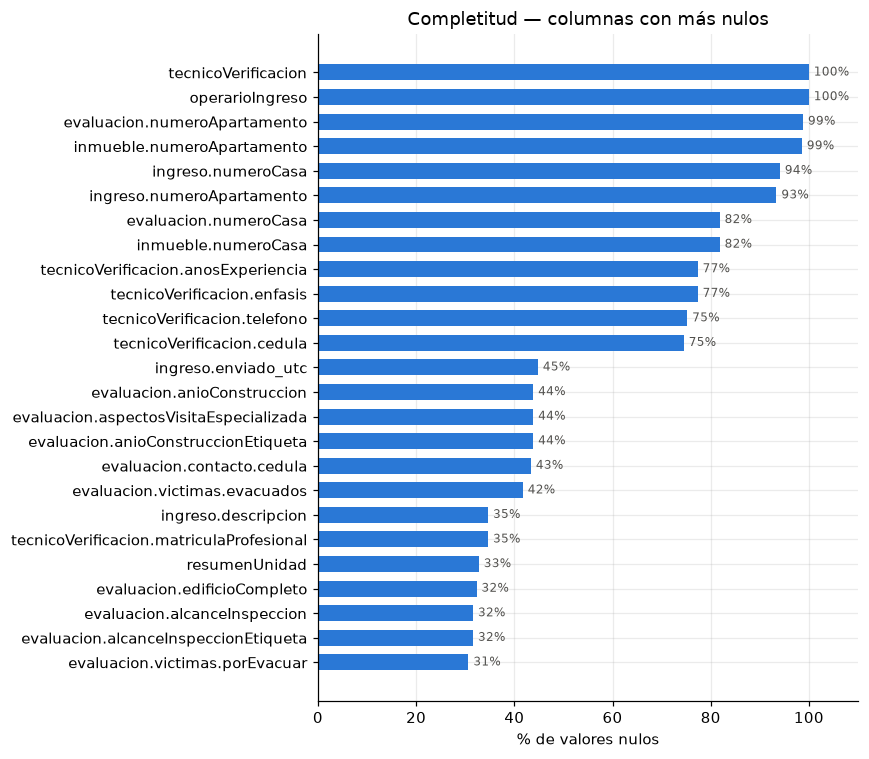

Columnas sin ningún nulo: 24 de 85


In [52]:
# Completitud: porcentaje de nulos por columna (las 25 más incompletas)
nulos = (df.isna().mean() * 100).sort_values(ascending=False)
top = nulos.head(25).iloc[::-1]
fig, ax = plt.subplots(figsize=(8, 7))
ax.barh(top.index, top.values, color=AZUL, height=0.65)
ax.set_xlabel("% de valores nulos")
ax.set_title("Completitud — columnas con más nulos")
for y, v in enumerate(top.values):
    ax.text(v + 1, y, f"{v:.0f}%", va="center", fontsize=8, color="#52514e")
ax.set_xlim(0, 110)
plt.tight_layout(); plt.show()
print(f"Columnas sin ningún nulo: {(nulos == 0).sum()} de {len(nulos)}")

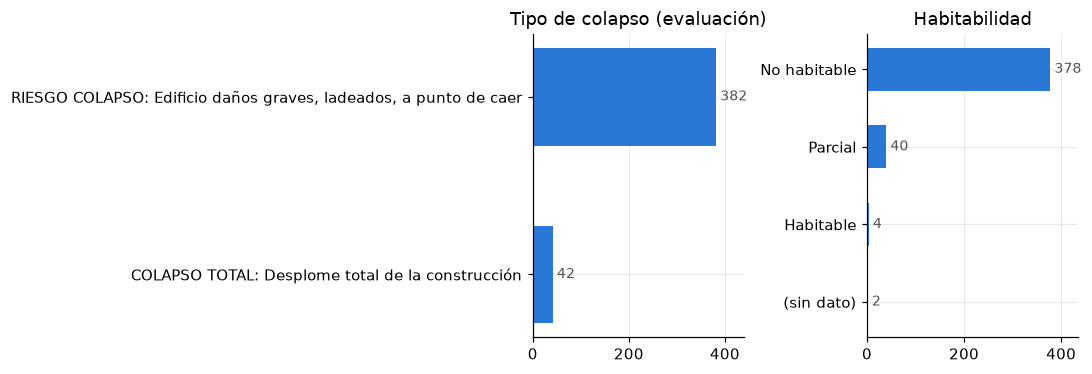

In [53]:
# Tipo de colapso verificado y habitabilidad
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
tc = df["evaluacion.tipoColapsoEtiqueta"].fillna("(sin dato)").value_counts()
axes[0].barh(tc.index[::-1], tc.values[::-1], color=AZUL, height=0.55)
axes[0].set_title("Tipo de colapso (evaluación)")
hab = df["evaluacion.habitabilidadEtiqueta"].fillna("(sin dato)").value_counts()
axes[1].barh(hab.index[::-1], hab.values[::-1], color=AZUL, height=0.55)
axes[1].set_title("Habitabilidad")
for ax, s in ((axes[0], tc), (axes[1], hab)):
    for y, v in enumerate(s.values[::-1]):
        ax.text(v, y, f" {v}", va="center", fontsize=9, color="#52514e")
    ax.set_xlim(0, s.max() * 1.15)
plt.tight_layout(); plt.show()

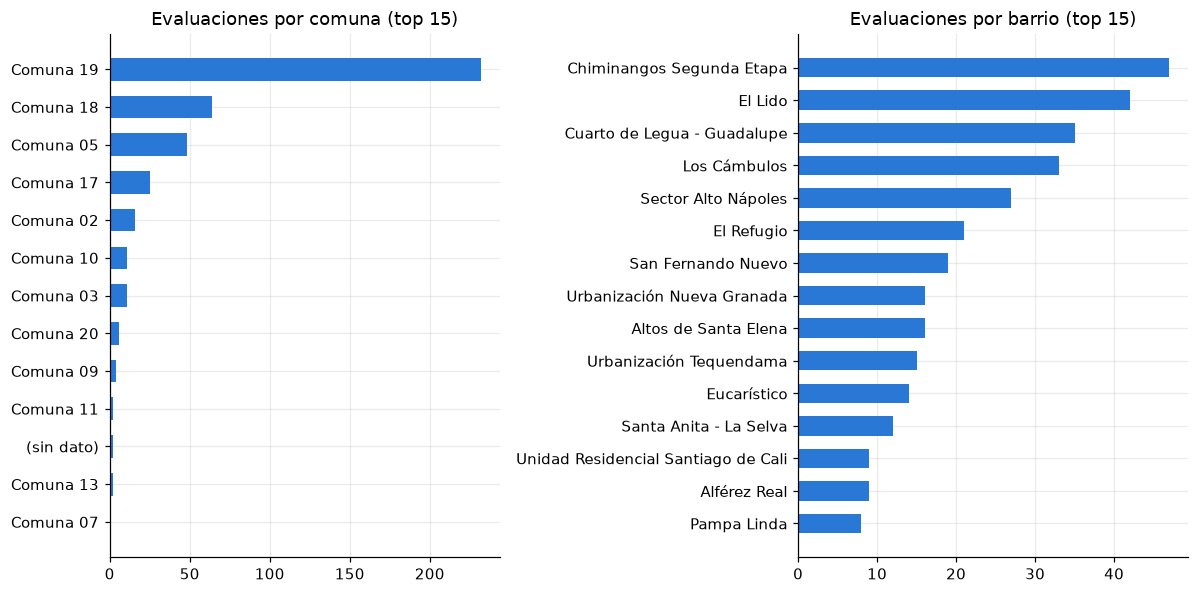

In [54]:
# Distribución territorial
fig, axes = plt.subplots(1, 2, figsize=(11, 5.5))
com = df["comunaEtiqueta"].fillna("(sin dato)").value_counts().head(15)
axes[0].barh(com.index[::-1], com.values[::-1], color=AZUL, height=0.6)
axes[0].set_title("Evaluaciones por comuna (top 15)")
bar = df["barrio"].fillna("(sin dato)").value_counts().head(15)
axes[1].barh(bar.index[::-1], bar.values[::-1], color=AZUL, height=0.6)
axes[1].set_title("Evaluaciones por barrio (top 15)")
plt.tight_layout(); plt.show()

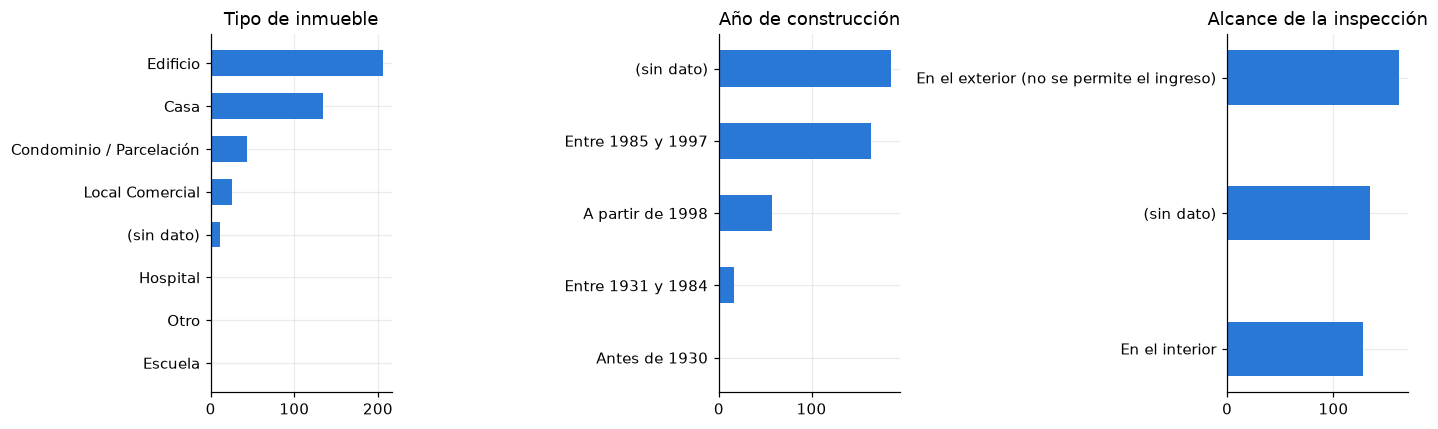

count    397.00
mean       5.11
std        2.38
min        1.00
25%        4.00
50%        5.00
75%        6.00
max       16.00


In [55]:
# Características del inmueble evaluado
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
ti = df["evaluacion.tipoInmuebleEtiqueta"].fillna("(sin dato)").value_counts().head(10)
axes[0].barh(ti.index[::-1], ti.values[::-1], color=AZUL, height=0.6)
axes[0].set_title("Tipo de inmueble")
an = df["evaluacion.anioConstruccionEtiqueta"].fillna("(sin dato)").value_counts()
axes[1].barh(an.index[::-1], an.values[::-1], color=AZUL, height=0.5)
axes[1].set_title("Año de construcción")
al = df["evaluacion.alcanceInspeccionEtiqueta"].fillna("(sin dato)").value_counts()
axes[2].barh(al.index[::-1], al.values[::-1], color=AZUL, height=0.4)
axes[2].set_title("Alcance de la inspección")
plt.tight_layout(); plt.show()
print(df["evaluacion.pisosSobreNivel"].describe().round(2).to_string())

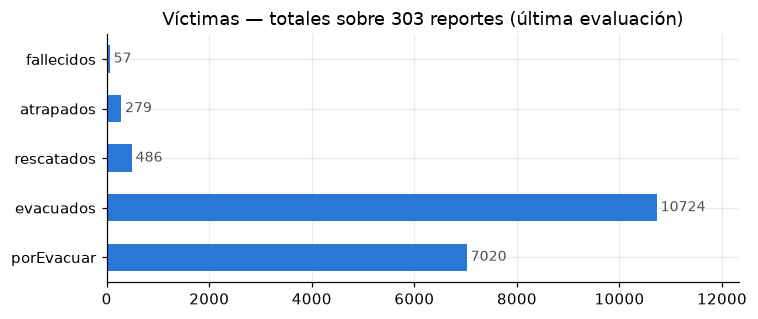

necesitaEvacuacion:
evaluacion.victimas.necesitaEvacuacion
True     264
False     38
None       1


In [56]:
# Víctimas: totales sobre el último estado de cada reporte (dedup por id,
# evaluación más reciente) para no doble-contar visitas repetidas
ult = (df.sort_values("evaluacion.creado_utc")
         .drop_duplicates("id", keep="last"))
vcols = ["evaluacion.victimas.fallecidos", "evaluacion.victimas.atrapados",
         "evaluacion.victimas.rescatados", "evaluacion.victimas.evacuados",
         "evaluacion.victimas.porEvacuar"]
tot = ult[vcols].apply(pd.to_numeric, errors="coerce").sum()
tot.index = [c.split(".")[-1] for c in tot.index]
fig, ax = plt.subplots(figsize=(7, 3))
ax.barh(tot.index[::-1], tot.values[::-1], color=AZUL, height=0.55)
for y, v in enumerate(tot.values[::-1]):
    ax.text(v, y, f" {int(v)}", va="center", fontsize=9, color="#52514e")
ax.set_xlim(0, tot.max() * 1.15)
ax.set_title(f"Víctimas — totales sobre {len(ult)} reportes (última evaluación)")
plt.tight_layout(); plt.show()
nec = ult["evaluacion.victimas.necesitaEvacuacion"].value_counts(dropna=False)
print("necesitaEvacuacion:")
print(nec.to_string())

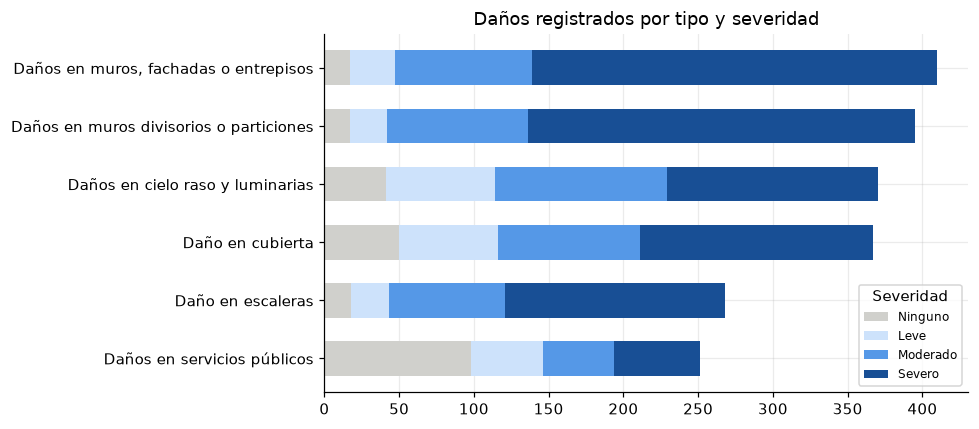

valor,Ninguno,Leve,Moderado,Severo
campo,,,,
"Daños en muros, fachadas o entrepisos",17,30,92,271
Daños en muros divisorios o particiones,17,25,94,259
Daños en cielo raso y luminarias,41,73,115,141
Daño en cubierta,50,66,95,156
Daño en escaleras,18,25,78,147
Daños en servicios públicos,98,48,48,57


In [57]:
# Daños: frecuencia de cada tipo de daño por severidad (todas las evaluaciones)
danos = pd.json_normalize(
    [{"campo": d["campoEtiqueta"], "valor": d.get("valorEtiqueta") or "(sin dato)"}
     for c in casos for d in (c.get("evaluacion", {}) or {}).get("danos") or []])
if len(danos):
    orden_sev = ["Ninguno", "Leve", "Moderado", "Severo"]
    ct = (pd.crosstab(danos["campo"], danos["valor"])
            .reindex(columns=[c for c in orden_sev if c in danos["valor"].unique()], fill_value=0))
    ct = ct.loc[ct.sum(axis=1).sort_values().index]
    colores = {"Ninguno": SEQ["none"], "Leve": SEQ["leve"],
               "Moderado": SEQ["moderado"], "Severo": SEQ["severo"]}
    fig, ax = plt.subplots(figsize=(9, max(4, 0.38 * len(ct))))
    izq = pd.Series(0, index=ct.index)
    for col in ct.columns:
        ax.barh(ct.index, ct[col], left=izq, color=colores[col], label=col, height=0.6)
        izq += ct[col]
    ax.legend(title="Severidad", loc="lower right", fontsize=8)
    ax.set_title("Daños registrados por tipo y severidad")
    plt.tight_layout(); plt.show()
    display(ct.iloc[::-1])
else:
    print("Sin registros de daños en el rango.")

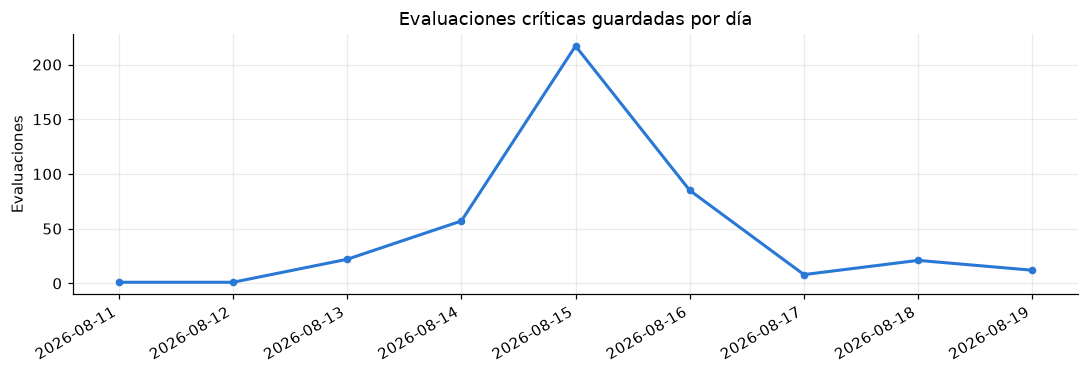

Rango temporal: 2026-08-11 12:00 a 2026-08-19 17:29 (Bogotá)


In [58]:
# Evolución temporal: evaluaciones críticas por día (hora de Bogotá)
fechas = pd.to_datetime(df["evaluacion.creado_utc"], unit="ms", utc=True).dt.tz_convert("America/Bogota")
por_dia = fechas.dt.date.value_counts().sort_index()
fig, ax = plt.subplots(figsize=(10, 3.5))
ax.plot(por_dia.index, por_dia.values, color=AZUL, linewidth=2, marker="o", markersize=4)
ax.set_title("Evaluaciones críticas guardadas por día")
ax.set_ylabel("Evaluaciones")
fig.autofmt_xdate()
plt.tight_layout(); plt.show()
print(f"Rango temporal: {fechas.min():%Y-%m-%d %H:%M} a {fechas.max():%Y-%m-%d %H:%M} (Bogotá)")

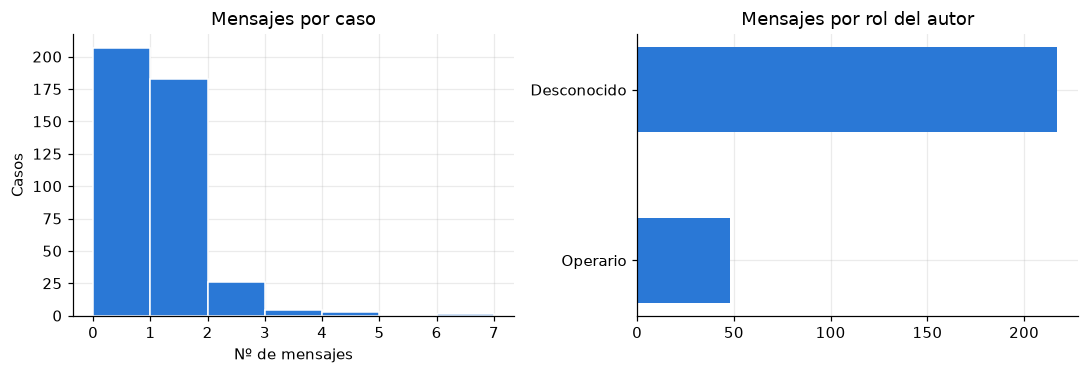

Casos con al menos un mensaje: 217 de 424


In [59]:
# Mensajes: volumen por caso y roles de los autores
n_msj = df["mensajes"].apply(lambda m: len(m) if isinstance(m, list) else 0)
roles = pd.Series([m["autor"]["rolEtiqueta"]
                   for c in casos for m in c.get("mensajes") or []]).value_counts()
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
axes[0].hist(n_msj, bins=range(0, int(n_msj.max()) + 2), color=AZUL, edgecolor="white")
axes[0].set_title("Mensajes por caso")
axes[0].set_xlabel("Nº de mensajes"); axes[0].set_ylabel("Casos")
if len(roles):
    axes[1].barh(roles.index[::-1], roles.values[::-1], color=AZUL, height=0.5)
    axes[1].set_title("Mensajes por rol del autor")
plt.tight_layout(); plt.show()
print(f"Casos con al menos un mensaje: {(n_msj > 0).sum()} de {len(df)}")

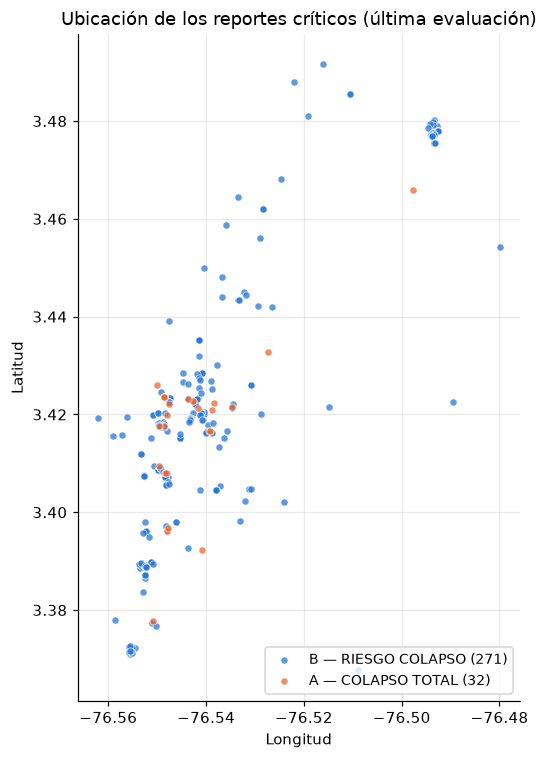

In [60]:
# Distribución espacial de los casos por tipo de colapso verificado
fig, ax = plt.subplots(figsize=(7, 7))
for codigo, color in (("B", AZUL), ("A", NARANJA)):
    sub = ult[ult["evaluacion.tipoColapso"] == codigo]
    ax.scatter(sub["lng"], sub["lat"], s=22, color=color, alpha=0.75,
               edgecolors="white", linewidths=0.5,
               label=f"{codigo} — {'COLAPSO TOTAL' if codigo == 'A' else 'RIESGO COLAPSO'} ({len(sub)})")
ax.set_title("Ubicación de los reportes críticos (última evaluación)")
ax.set_xlabel("Longitud"); ax.set_ylabel("Latitud")
ax.legend(fontsize=9)
ax.set_aspect("equal")
plt.tight_layout(); plt.show()

In [61]:
# placeId: procedencia de las coordenadas
origen = ult["placeId"].fillna("").map(
    lambda p: "manual" if p.startswith("manual:")
    else "verified" if p.startswith("verified:")
    else "google_places" if p else "(vacío)").value_counts()
print("Origen de coordenadas (placeId):")
print(origen.to_string())

Origen de coordenadas (placeId):
placeId
google_places    252
verified          51


In [62]:
# Resumen final
resumen = {
    "evaluaciones_crudas": len(df),
    "reportes_unicos": int(df["id"].nunique()),
    "colapso_A_total": int((ult["evaluacion.tipoColapso"] == "A").sum()),
    "colapso_B_riesgo": int((ult["evaluacion.tipoColapso"] == "B").sum()),
    "comunas_distintas": int(df["comuna"].nunique()),
    "barrios_distintos": int(df["barrio"].nunique()),
    "casos_con_tecnico_asignado": int(df["tecnicoVerificacion.id"].notna().sum()) if "tecnicoVerificacion.id" in df else 0,
    "generado": ms_a_fecha(data["generado_utc"]),
}
print(json.dumps(resumen, indent=2, ensure_ascii=False))

{
  "evaluaciones_crudas": 424,
  "reportes_unicos": 303,
  "colapso_A_total": 32,
  "colapso_B_riesgo": 271,
  "comunas_distintas": 12,
  "barrios_distintos": 63,
  "casos_con_tecnico_asignado": 337,
  "generado": "2026-08-19 17:47:46"
}


## Conclusiones

- La API tiene **un único endpoint** (`GET /api/operario/reports/visitados-criticos`)
  que devuelve el universo completo de casos críticos (colapso verificado A o B) del
  rango pedido, con granularidad de **evaluación** — para análisis por inmueble hay
  que deduplicar por `id` quedándose con la `evaluacion.creado_utc` más reciente
  (es lo que hace `integracion_F1/integracion/api_visitados.py`).
- La estructura anidada tiene 7 bloques: raíz (ubicación), `ingreso`, `contacto`,
  `inmueble`, personal (`operarioIngreso` / `tecnicoVerificacion`), `evaluacion`
  (con `danos[]` y `victimas`) y `mensajes[]`.
- El filtro temporal aplica sobre `evaluacion.creado_utc`, no sobre la fecha del
  reporte de ingreso — relevante para ventanas diarias en hora de Colombia (UTC−5).
- La API expone **datos personales en claro** (contactos, cédulas, teléfonos del
  personal técnico): cualquier exportación derivada debe enmascararlos, como se
  hizo en los ejemplos de este notebook.


---

# API `/api/informe/json` — Informe completo con fotos

Segundo endpoint disponible: exportación **JSON** de reportes con datos de visita
(evaluación v1) y enlaces a fotografías, pensada para integraciones externas. Es el
equivalente funcional al Excel de `GET /api/informe/export`, con campos adicionales
(`id`, fotos de la evaluación y fotos del chat).

**Diferencias frente a `visitados-criticos`:**

| | `visitados-criticos` | `/api/informe/json` |
| --- | --- | --- |
| Alcance | Solo críticos verificados A/B | **Todos** los reportes (filtrable) |
| Granularidad | Una fila por **evaluación** | Una fila por **reporte** |
| Formato de valores | Código + etiqueta (`valor`/`valorEtiqueta`) | Texto ya formateado `es-CO` |
| Fotos | No incluye | **Sí** (evaluación v1 + chat) |
| Rango de fechas | Obligatorio, sobre `evaluacion.creado_utc` | Opcional, sobre `reports.createdAt` |
| Auth | Basic (solo operario) | Basic (operario **o** viewer) |
| Paginación | No | No (acotar con filtros) |

## Endpoint

```
GET https://atencionsismo.cali.gov.co/api/informe/json
```

HTTP **Basic Auth** (operario **o** viewer de solo lectura). Content-Type de
respuesta `application/json`, tiempo máximo 60 s. **No pagina**: devuelve el
conjunto completo que coincide con los filtros.

En este proyecto reutiliza las mismas credenciales del `.env`
(`VISITADOS_API_USER` / `VISITADOS_API_PASS`) siempre que ese usuario tenga rol
operario o viewer habilitado.

> ⚠️ **Sin filtros el servidor devuelve `504 Gateway Time-out`.** El payload
> completo (todos los reportes con fotos y mensajes inline) no cabe en el límite de
> 60 s. Medido en vivo: `verif=critical` → 200 en ~38 s (68 reportes, 275 KB);
> `verif=visited` → 200 pero pesado (~916 reportes, 4.2 MB, ~130 s);
> `verif=visited,critical` y sin filtro → time-out. **Acotá siempre** con `verif`,
> `comuna`, `q` o un rango `desde_utc`/`hasta_utc`.

### Parámetros de consulta (todos opcionales)

| Parámetro | Tipo | Descripción |
| --- | --- | --- |
| `comuna` | CSV de enteros | Ej. `comuna=14,15` |
| `barrio` | CSV de strings | Ej. `barrio=San Antonio,Granada` |
| `verif` | CSV | `pending`, `assigned`, `visited`, `critical`, `unavailable`, `ede` |
| `afectacion` | CSV | Tipos de colapso: `A`–`F`, `unset` |
| `inmueble` | CSV | Tipos de inmueble del catálogo |
| `q` | string | Búsqueda libre (dirección, contacto, barrio…) |
| `desde_utc` | entero (ms UTC) | Inclusive. Filtra `reports.createdAt` |
| `hasta_utc` | entero (ms UTC) | Inclusive. `desde_utc <= hasta_utc` |

`page` se acepta por compatibilidad pero se ignora (no hay paginación).

### Errores

| HTTP | Causa |
| --- | --- |
| `400` | `desde_utc`/`hasta_utc` inválido o rango inconsistente |
| `401` | Sin `Authorization`, credenciales inválidas o correo no autorizado |
| `403` | Usuario válido pero sin contraseña creada en el portal |
| `500` | Error interno |
| `504` | Consulta demasiado amplia (sin filtros): supera el límite de 60 s |

In [63]:
# Segundo endpoint: informe JSON completo + fotos.
# Reutiliza las MISMAS credenciales Basic Auth ya cargadas del .env (usuario, clave).
INFORME_JSON_URL = "https://atencionsismo.cali.gov.co/api/informe/json"

# OJO: sin filtros la respuesta trae TODOS los reportes con fotos y mensajes
# inline -> supera el límite de 60 s del servidor y devuelve 504 Gateway Time-out.
# Hay que acotar. `verif=critical` es un set rico y liviano (evaluación + fotos +
# mensajes) que responde en segundos; `verif=visited` funciona pero es pesado (~4 MB).
resp2 = requests.get(INFORME_JSON_URL, params={"verif": "critical"},
                     auth=(usuario, clave), timeout=120)
resp2.raise_for_status()
data2 = resp2.json()
print(f"HTTP {resp2.status_code} — {len(resp2.content):,} bytes")
print(f"Reportes devueltos (verif=critical): {data2['cantidad']}")
reportes = data2["reportes"]

HTTP 200 — 275,331 bytes
Reportes devueltos (verif=critical): 68


### Respuesta exitosa (`200`) — nivel superior

| Campo | Tipo | Descripción |
| --- | --- | --- |
| `ok` | boolean | `true` si la petición fue válida |
| `cantidad` | number | Número de elementos en `reportes` |
| `generado_utc` | number | Momento de generación (ms UTC) |
| `desde_utc` | number \| null | Eco del filtro (o `null`) |
| `hasta_utc` | number \| null | Eco del filtro (o `null`) |
| `reportes` | array | Lista de reportes (**uno por reporte**) |

In [64]:
meta2 = {k: v for k, v in data2.items() if k != "reportes"}
meta2_legible = {**meta2, "generado_utc (Bogotá)": ms_a_fecha(meta2["generado_utc"])}
print(json.dumps(meta2_legible, indent=2, ensure_ascii=False))

{
  "ok": true,
  "cantidad": 68,
  "generado_utc": 1787179693401,
  "desde_utc": null,
  "hasta_utc": null,
  "generado_utc (Bogotá)": "2026-08-19 17:48:13"
}


### Esquema de cada reporte (`reportes[]`)

Los valores de texto vienen **formateados para lectura humana** (etiquetas en
español, fechas localizadas `es-CO`, teléfonos formateados). Coinciden con las
columnas del Excel de `/api/informe/export`, más tres campos extra.

**Identificación y ubicación**

| Campo | Descripción |
| --- | --- |
| `id` | Identificador único del reporte en InstantDB (**extra**) |
| `nombre` / `cedula` / `telefono` | Contacto del ciudadano |
| `direccion` / `barrio` / `comuna` | Ubicación |
| `latitud` / `longitud` | Coordenadas (string) |
| `estadoVerificacion` | Ej. `"Visitado crítico"` |
| `afectacion` | Ej. `"A — Colapso total"` |

**Inmueble e ingreso**

| Campo | Descripción |
| --- | --- |
| `tipoInmueble` / `nombreEdificio` / `apartamento` / `casa` | Datos del inmueble |
| `predioCompleto` | `"Sí"` / `"No"` |
| `descripcion` | Descripción del caso |
| `fechaCreacion` / `fechaEnvio` / `fechaVencimiento` | Fechas `es-CO` |
| `completado` | `"Sí"` / `"No"` |

**Visita técnica (evaluación v1)**

| Campo | Descripción |
| --- | --- |
| `visitado` / `pudoEvaluar` | `"Sí"` / `"No"` |
| `motivoNoEvaluacion` / `otroMotivoNoEvaluacion` | Motivos si no se pudo evaluar |
| `pisos` / `sotanos` / `anoConstruccion` | Características |
| `alcanceInspeccion` | Ej. `"Exterior e interior"` |
| `danosMurosFachadas` / `danosParticiones` / `danosCieloRaso` / `danosCubierta` / `danosEscaleras` / `danosServiciosPublicos` | Severidad por elemento (`Sin daño`/`Leve`/`Moderado`/`Severo`) |
| `fallecidos` / `atrapados` / `rescatados` / `evacuados` / `porEvacuar` | Víctimas |
| `necesitaEvacuacion` | `"Sí"` / `"No"` |
| `habitabilidad` | Ej. `"No habitable"` |
| `conceptoTecnico` / `aspectosVisitaEspecializada` | Texto libre del técnico |
| `fechaEvaluacion` | Fecha de la evaluación `es-CO` |

**Campos extra (no están en el Excel)**

| Campo | Estructura | Descripción |
| --- | --- | --- |
| `id` | string | ID del reporte en InstantDB |
| `fotografiasEvaluacion` | `[{ id, url }]` | Fotos de la **evaluación v1 más reciente** |
| `mensajes` | `[{ id, texto, creado_utc, fotografias[] }]` | Chat del reporte (asc por fecha) |

Cada foto: `id` (archivo en `$files`) + `url` (Instant Storage, usable directo en
`<img src>` o descarga HTTP). En `mensajes`, solo se incluyen fotos con `id` y `url`
válidos.

In [65]:
# Un reporte de ejemplo, con datos personales enmascarados (reusa redactar())
# y con las listas de fotos/mensajes recortadas para ver la forma.
muestra = redactar(dict(reportes[0]))
if isinstance(muestra.get("fotografiasEvaluacion"), list):
    muestra["fotografiasEvaluacion"] = muestra["fotografiasEvaluacion"][:1]
if isinstance(muestra.get("mensajes"), list):
    muestra["mensajes"] = muestra["mensajes"][:1]
print(json.dumps(muestra, indent=2, ensure_ascii=False))

{
  "id": "560cac07-71ef-4cc4-b02e-a2db0e3ae662",
  "nombre": "***",
  "cedula": "***",
  "telefono": "***",
  "direccion": "Cl. 8 Oe. #28-08, El Sindicato, Cali, Valle del Cauca",
  "barrio": "Tejares - Cristales",
  "comuna": "19",
  "estadoVerificacion": "Visitado Crítico",
  "afectacion": "RIESGO COLAPSO: Edificio daños graves, ladeados, a punto de caer",
  "tipoInmueble": "Casa",
  "nombreEdificio": "",
  "apartamento": "",
  "casa": "",
  "predioCompleto": "No",
  "descripcion": "",
  "latitud": "3.4392115",
  "longitud": "-76.5475842",
  "fechaCreacion": "19/08/26, 9:38 p. m.",
  "fechaEnvio": "19/08/26, 9:41 p. m.",
  "fechaVencimiento": "",
  "completado": "Sí",
  "pudoEvaluar": "Sí",
  "motivoNoEvaluacion": "",
  "otroMotivoNoEvaluacion": "",
  "pisos": "1",
  "sotanos": "0",
  "anoConstruccion": "Entre 1985 y 1997",
  "alcanceInspeccion": "En el exterior (no se permite el ingreso)",
  "danosMurosFachadas": "Severo",
  "danosParticiones": "Severo",
  "danosCieloRaso": "Severo

### Alcance y limitaciones

**Incluido:** datos del reporte (ciudadano), evaluación de verificación **v1**,
fotos de la evaluación v1, mensajes del chat con sus fotos, estado de verificación
(detecta EDE v2 para la etiqueta, sin exportar el detalle EDE).

**No incluido:** detalle de evaluaciones **EDE v2** (`evaluationsV2`), datos **RUFE**,
`accessSecret` del reporte, y paginación (acotar con filtros / rango de fechas).

### APIs relacionadas

| Endpoint | Formato | Auth | Uso |
| --- | --- | --- | --- |
| `GET /api/informe` | JSON resumido | Sesión Instant (Bearer) | Tabla UI `/informe` |
| `GET /api/informe/export` | Excel | Sesión Instant (Bearer) | Descarga del portal |
| `GET /api/informe/json` | JSON completo + fotos | Basic Auth | Integraciones externas |
| `GET /api/operario/reports/visitados-criticos` | JSON críticos A/B | Basic Auth (operario) | Casos críticos visitados |

> **Privacidad:** igual que el otro endpoint, `/api/informe/json` devuelve datos
> personales en claro (nombre, cédula, teléfono). Cualquier exportación derivada
> debe enmascararlos — por eso los ejemplos reutilizan `redactar()`.